In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host=os.environ.get('DB_HOST', os.environ.get('POSTGRES_HOST', 'localhost')),
    port=os.environ.get('DB_PORT', os.environ.get('POSTGRES_PORT', '5432')),
    user=os.environ.get('DB_USER', os.environ.get('POSTGRES_USER', 'postgres')),
    password=os.environ.get('DB_PASSWORD', os.environ.get('POSTGRES_PASSWORD', 'postgres')),
    dbname=os.environ.get('DB_NAME', os.environ.get('POSTGRES_DB', 'olist'))
)

with open('../../sql/analysis/03_delivery_sla_performance.sql', 'r') as f:
    sql_script = f.read()

queries = [q + ';' for q in sql_script.split(';') if q.strip()]

df1 = pd.read_sql(queries[0], conn)
df2 = pd.read_sql(queries[1], conn)

display(df1)
display(df2.head(10))

/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66168/1992110127.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66168/1992110127.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(queries[1], conn)


,total_deliveries,total_delayed_orders,delayed_rate_pct,avg_actual_delivery_days,avg_estimated_delivery_days
0,96478,7826,8.11,12.558217,23.736347


,customer_state,total_deliveries,delayed_orders,delayed_rate_pct,avg_delay_days_when_delayed
0,AL,397,95,23.93,9.246130
1,MA,717,141,19.67,9.970709
2,PI,476,76,15.97,12.298219
3,CE,1279,196,15.32,14.326787
4,SE,335,51,15.22,16.890978
5,BA,3256,457,14.04,11.099223
6,RJ,12350,1664,13.47,12.848692
7,TO,274,35,12.77,5.651584
8,PA,946,117,12.37,12.303485
9,ES,1995,244,12.23,10.596163


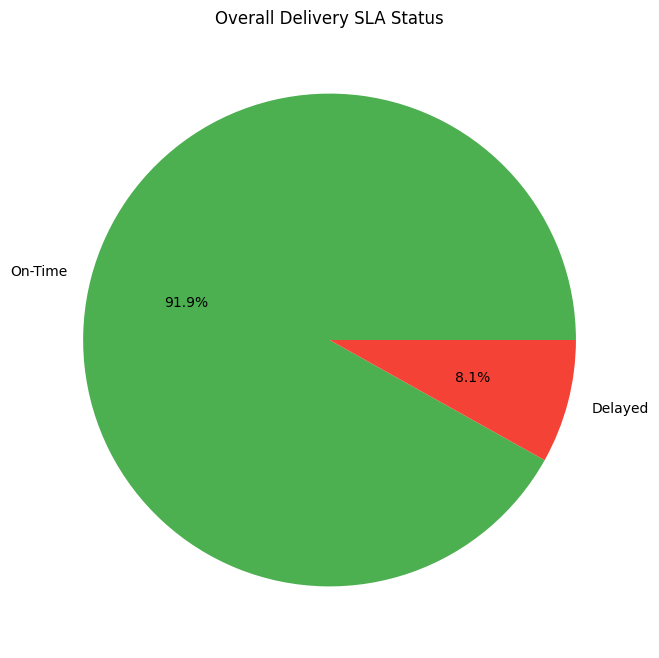

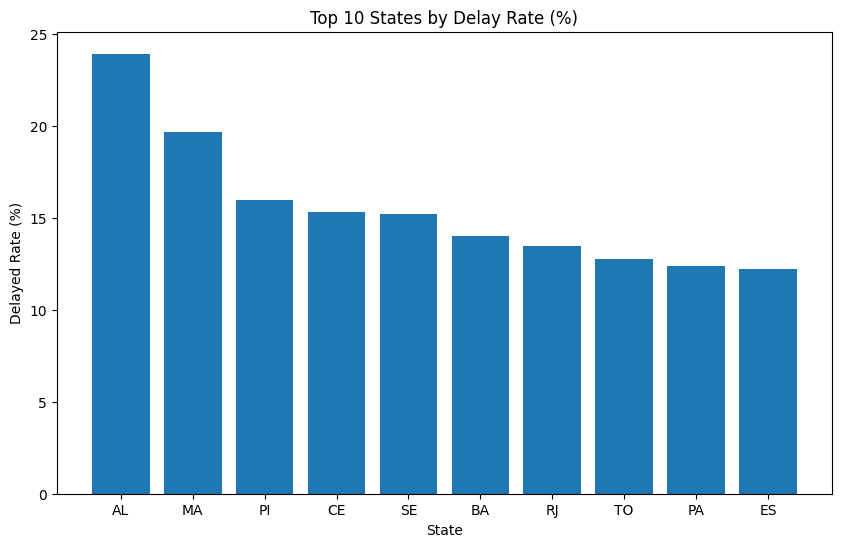

In [2]:
fig1, ax1 = plt.subplots(figsize=(8, 8))
on_time = df1['total_deliveries'].iloc[0] - df1['total_delayed_orders'].iloc[0]
delayed = df1['total_delayed_orders'].iloc[0]
ax1.pie([on_time, delayed], labels=['On-Time', 'Delayed'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
ax1.set_title('Overall Delivery SLA Status')
fig1.savefig('../figures/03_sla_pie.png', bbox_inches='tight')
plt.show()

top_states = df2.head(10)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(top_states['customer_state'], top_states['delayed_rate_pct'])
ax2.set_title('Top 10 States by Delay Rate (%)')
ax2.set_xlabel('State')
ax2.set_ylabel('Delayed Rate (%)')
fig2.savefig('../figures/03_delay_by_state.png', bbox_inches='tight')
plt.show()

### Key Findings
- A notable proportion of orders miss the estimated SLA delivery dates.
- Geographic location heavily influences delivery delay rates.